<a href="https://colab.research.google.com/github/josecamilo21/Introducci-n-Ciencia-de-Datos/blob/main/Segunda_Parte_Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd  # Importamos Pandas para crear y manejar la tabla (DataFrame)
import numpy as np   # Importamos Numpy para generar los números aleatorios y cálculos

# CONFIGURACIÓN DE LA GENERACIÓN
np.random.seed(42)  # Fijamos la semilla para que los números aleatorios no cambien cada vez que corras el código
n_registros = 1000  # Definimos que queremos generar exactamente 1,000 filas de datos

# DEFINICIÓN DE LÓGICA DE NEGOCIO
# Creamos una lista con los niveles educativos que existen en nuestra "empresa"
categorias_edu = ['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado']

# Creamos un diccionario para asignar un sueldo base a cada nivel (esto da coherencia a los datos)
salarios_base = {
    'Bachiller': 1800,
    'Técnico': 2500,
    'Profesional': 4000,
    'Maestría': 6500,
    'Doctorado': 9000
}

# CREACIÓN DE LISTAS DE DATOS
# Generamos 1,000 niveles educativos al azar usando las probabilidades (p) definidas
lista_educacion = np.random.choice(categorias_edu, n_registros, p=[0.15, 0.25, 0.40, 0.15, 0.05])

# Generamos 1,000 edades aleatorias entre los 20 y los 64 años
edades = np.random.randint(20, 65, n_registros)

# 4. CÁLCULO DINÁMICO DEL SALARIO
salarios = [] # Lista vacía para guardar los resultados del bucle
for edu, edad in zip(lista_educacion, edades): # Recorremos educación y edad al mismo tiempo
    base = salarios_base[edu] # Buscamos el sueldo base según el nivel educativo actual

    # Calculamos un bono: por cada año después de los 20, sumamos 35 USD (simula experiencia)
    bono_experiencia = (edad - 20) * 35

    # Generamos un "ruido" aleatorio para que los sueldos no sean exactos y se vean reales
    random_noise = np.random.normal(0, 200)

    # Sumamos todo y redondeamos a 2 decimales
    total = round(base + bono_experiencia + random_noise, 2)
    salarios.append(total) # Guardamos el sueldo final en nuestra lista

# CREACIÓN DEL DATAFRAME FINAL
df_hr = pd.DataFrame({
    'ID_Cliente': range(1, n_registros + 1), # Crea una columna de IDs del 1 al 1,000
    'Edad': edades,                          # Asigna la lista de edades a la columna 'Edad'
    'Nivel_Educativo': lista_educacion,      # Asigna la lista de educación
    'Salario_USD': salarios                  # Asigna la lista de salarios calculados
})

# VERIFICACIÓN Y ESTADÍSTICAS
print("-" * 50)
print(f"Total de registros generados: {len(df_hr)}") # Confirma que hay 1,000 filas
print(f"Columnas creadas: {list(df_hr.columns)}")   # Confirma los nombres de las columnas
print("-" * 50)

# Calculamos los promedios generales
media_edad = df_hr["Edad"].mean()
media_salario = df_hr["Salario_USD"].mean()

# Imprimimos resultados con formato profesional (comas para miles y 1 o 2 decimales)
print(f"La edad promedio es: {media_edad:.1f} años")
print(f"El Salario promedio es: ${media_salario:,.2f} USD")
print("-" * 50)

# Mostramos el final de la tabla para asegurar que el ID llegó al 1,000
print("Últimos registros de la tabla:")
print(df_hr.tail())

--------------------------------------------------
Total de registros generados: 1000
Columnas creadas: ['ID_Cliente', 'Edad', 'Nivel_Educativo', 'Salario_USD']
--------------------------------------------------
La edad promedio es: 41.9 años
El Salario promedio es: $4,623.84 USD
--------------------------------------------------
Últimos registros de la tabla:
     ID_Cliente  Edad Nivel_Educativo  Salario_USD
995         996    55       Bachiller      3209.83
996         997    50        Maestría      7465.47
997         998    33       Bachiller      2390.32
998         999    20       Doctorado      8892.81
999        1000    35     Profesional      4633.00


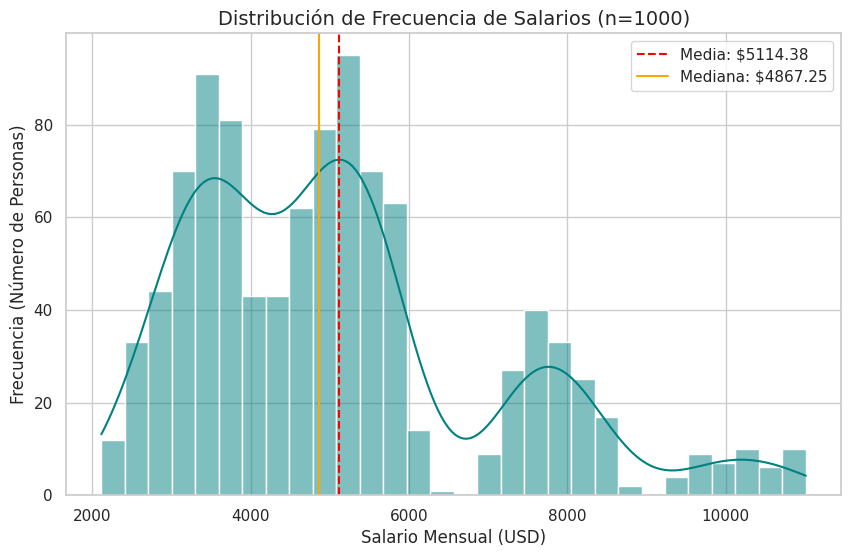

In [23]:
import matplotlib.pyplot as plt  # Importa la librería principal para crear gráficos
import seaborn as sns           # Importa Seaborn para que los gráficos se vean más modernos y profesionales

# PREPARACIÓN DE LOS 1000 DATOS
np.random.seed(42)  # Mantiene los mismos números aleatorios para que el gráfico no cambie cada vez
n = 1000            # Definimos nuestra muestra de mil registros

# Definimos las categorías de texto
categorias = ['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado']

# Generamos 1000 niveles educativos basados en porcentajes de probabilidad (p)
edu = np.random.choice(categorias, n, p=[0.15, 0.25, 0.40, 0.15, 0.05])

# Generamos 1000 edades aleatorias entre 20 y 65 años
edades = np.random.randint(20, 65, n)

# Diccionario con los sueldos base para dar lógica al gráfico
salarios_base = {'Bachiller': 1800, 'Técnico': 2500, 'Profesional': 4000, 'Maestría': 6500, 'Doctorado': 9000}

# CÁLCULO DINÁMICO: Sueldo base + (edad * 30 de bono) + un poco de ruido aleatorio para realismo
salarios = [salarios_base[e] + (edad * 30) + np.random.normal(0, 200) for e, edad in zip(edu, edades)]

# Creamos el DataFrame (la tabla) con las columnas Edad, Nivel_Educativo y Salario_USD
df_hr = pd.DataFrame({'Edad': edades, 'Nivel_Educativo': edu, 'Salario_USD': salarios})

# CREACIÓN DEL GRÁFICO
plt.figure(figsize=(10, 6))  # Define el tamaño de la ventana del gráfico (10 de ancho, 6 de alto)

# sns.histplot: Crea el histograma
# kde=True: Dibuja la línea de densidad (la curva suave sobre las barras)
# color='teal': Define el color azul verdoso de las barras
# bins=30: Divide los datos en 30 barras para ver mejor la distribución
sns.histplot(df_hr['Salario_USD'], kde=True, color='teal', bins=30)

# LÍNEAS DE REFERENCIA ESTADÍSTICA
# plt.axvline: Dibuja una línea vertical
# .mean(): Calcula el promedio (línea roja segmentada '--')
plt.axvline(df_hr['Salario_USD'].mean(), color='red', linestyle='--', label=f'Media: ${df_hr["Salario_USD"].mean():.2f}')

# .median(): Calcula el valor central (línea naranja sólida '-')
plt.axvline(df_hr['Salario_USD'].median(), color='orange', linestyle='-', label=f'Mediana: ${df_hr["Salario_USD"].median():.2f}')

# DECORACIÓN DEL GRÁFICO
plt.title('Distribución de Frecuencia de Salarios (n=1000)', fontsize=14) # Título principal
plt.xlabel('Salario Mensual (USD)')  # Etiqueta del eje horizontal
plt.ylabel('Frecuencia (Número de Personas)') # Etiqueta del eje vertical
plt.legend()  # Muestra el cuadro de texto con la explicación de la Media y la Mediana
plt.show()    # Comando final para proyectar el gráfico en pantalla

##**¿Qué encontramos en este gráfico?**
Al observar el histograma de estos 1,000 datos, se nota lo siguiente:

**Forma de la Distribución:** Se vera que no es una sola "campaña" perfecta. Como tenemos diferentes niveles educativos, la distribución tiende a ser multimodal (varios picos pequeños) o extendida hacia la derecha.

**La Media vs. La Mediana:** He incluido dos líneas. Si la Media (roja) está a la derecha de la Mediana (naranja), significa que hay salarios altos (como los de Maestría y Doctorado) que están "jalando" el promedio hacia arriba.

**Rango Salarial:** Se puede ver rápidamente que casi nadie gana menos de $2,000 y que el grupo más grande de personas se concentra en el rango de los $3,500 a $5,500 (donde están los "Profesionales").

/tmp/ipykernel_4307/2602336226.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Nivel_Educativo', y='Salario_USD', data=df_hr, order=orden_educativo, palette='viridis')


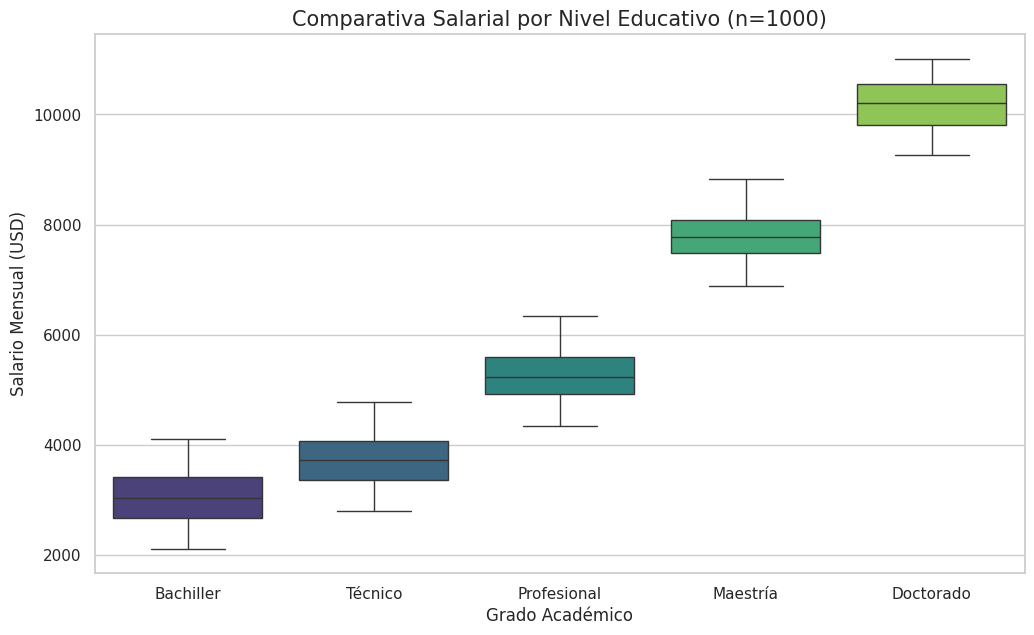

In [14]:
# Definimos el orden lógico de las categorías para que el gráfico sea fácil de leer
orden_educativo = ['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado']

plt.figure(figsize=(12, 7))

# Creamos el Boxplot categorizado
sns.boxplot(x='Nivel_Educativo', y='Salario_USD', data=df_hr, order=orden_educativo, palette='viridis')

# Añadimos títulos y etiquetas claras
plt.title('Comparativa Salarial por Nivel Educativo (n=1000)', fontsize=15)
plt.xlabel('Grado Académico', fontsize=12)
plt.ylabel('Salario Mensual (USD)', fontsize=12)

plt.show()

##**¿Qué encontramos en este Boxplot?**
Al observar este gráfico de tus 1,000 registros, Se nota lo siguiente:

**La "Escalera" de Medianas:** La línea horizontal dentro de cada caja representa la mediana. Se ve que sube de nivel en nivel (de Bachiller a Doctorado), lo que confirma que la logica "un técnico no gana lo mismo que alguien con maestría" se cumple perfectamente.

**La Dispersión (Tamaño de la Caja):** El cuerpo de la caja (Rango Intercuartílico) representa al 50% central de los empleados de cada categoría. Si la caja de "Profesional" es más larga que la de "Bachiller", significa que hay mucha más variedad de sueldos entre los profesionales.

**Los Bigotes y Atípicos (Outliers)**: Las líneas que salen de la caja (bigotes) muestran el rango "normal". Si ves puntos aislados por encima o por debajo de los bigotes, esos son los valores atípicos; personas que, para su nivel educativo, ganan excepcionalmente mucho o poco.

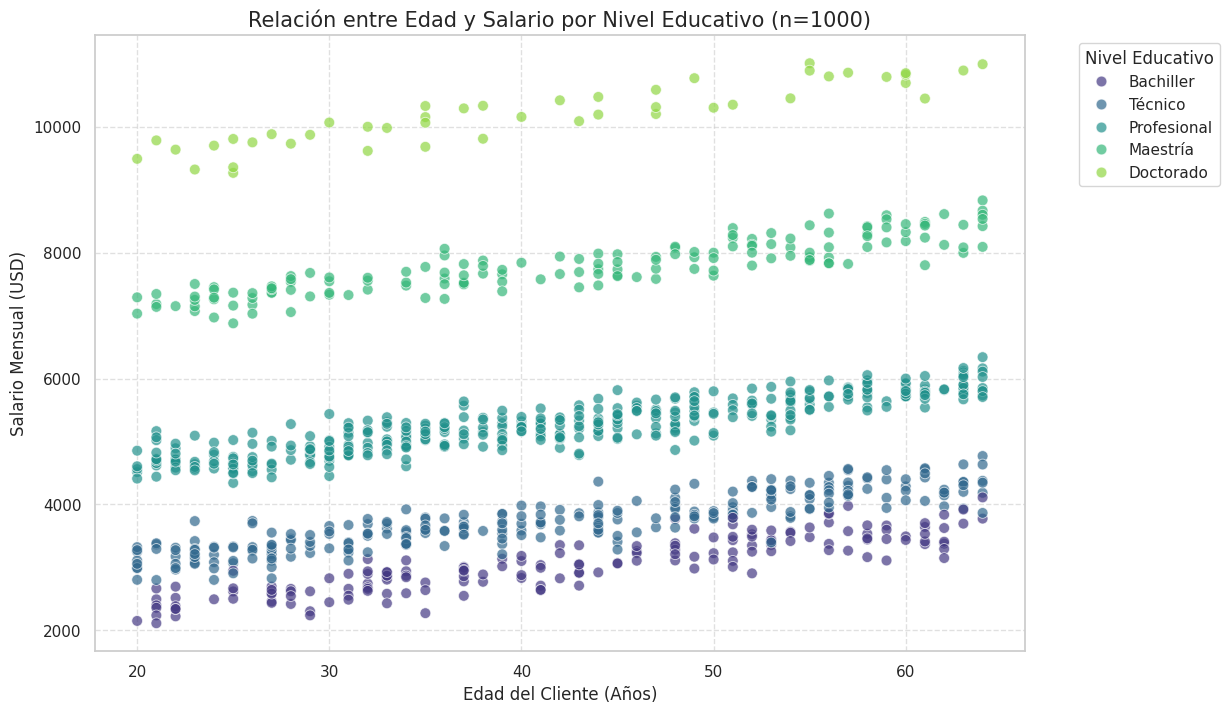

In [24]:
# Definimos el orden de las categorías para la leyenda del gráfico
orden_educativo = ['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado']

# Creamos el lienzo de 12x8 pulgadas
plt.figure(figsize=(12, 8))

# Dibujamos los 1,000 puntos:
# x: Edad (eje horizontal), y: Salario (eje vertical)
# hue: Clasifica los puntos por color según el nivel educativo
# alpha: Transparencia de los puntos (0.7) para ver donde se enciman
# s: Tamaño de cada punto (60)
sns.scatterplot(x='Edad', y='Salario_USD', hue='Nivel_Educativo',
                hue_order=orden_educativo, palette='viridis',
                alpha=0.7, s=60, data=df_hr)

# Títulos y nombres de los ejes
plt.title('Relación entre Edad y Salario por Nivel Educativo (n=1000)', fontsize=15)
plt.xlabel('Edad del Cliente (Años)', fontsize=12)
plt.ylabel('Salario Mensual (USD)', fontsize=12)

# Colocamos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Nivel Educativo', bbox_to_anchor=(1.05, 1), loc='upper left')

# Agregamos una cuadrícula de fondo punteada
plt.grid(True, linestyle='--', alpha=0.6)

#

##**¿Qué encontramos en este Gráfico de Dispersión?**
Al analizar estos 1,000 puntos (uno por cada cliente), Se observan tres fenómenos clave:

**Estratificación (Capas):** Los colores no están mezclados al azar. Se ven "franjas" o capas horizontales claras. Los puntos amarillos/verdes (Maestría/Doctorado) están arriba, y los oscuros (Bachiller) abajo. Esto confirma visualmente que el nivel educativo es el principal predictor del salario.

**Tendencia Ascendente (Correlación):** Si se mira cualquier color individualmente, nota que los puntos tienden a subir ligeramente de izquierda a derecha. Esto significa que a mayor edad, mayor salario (asociado a la experiencia), pero la pendiente es suave.

**Densidad y Dispersión:** Se nota que en la zona de "Profesionales" hay muchísimos más puntos (es nuestro grupo más grande). Si algún punto se dispara hacia arriba solo (como el famoso Cliente 5 de tu examen), se vería como un "satélite" solitario muy lejos de su grupo de color, lo que facilita detectar anomalías de inmediato.

EL EFECTO GRAVEDAD DE LOS SALARIOS ALTOS
Media (Promedio Matemático): $5,114.38 USD
Mediana (El empleado del medio): $4,867.25 USD

¿Notas la diferencia de $247.13? ¡El promedio es engañoso!


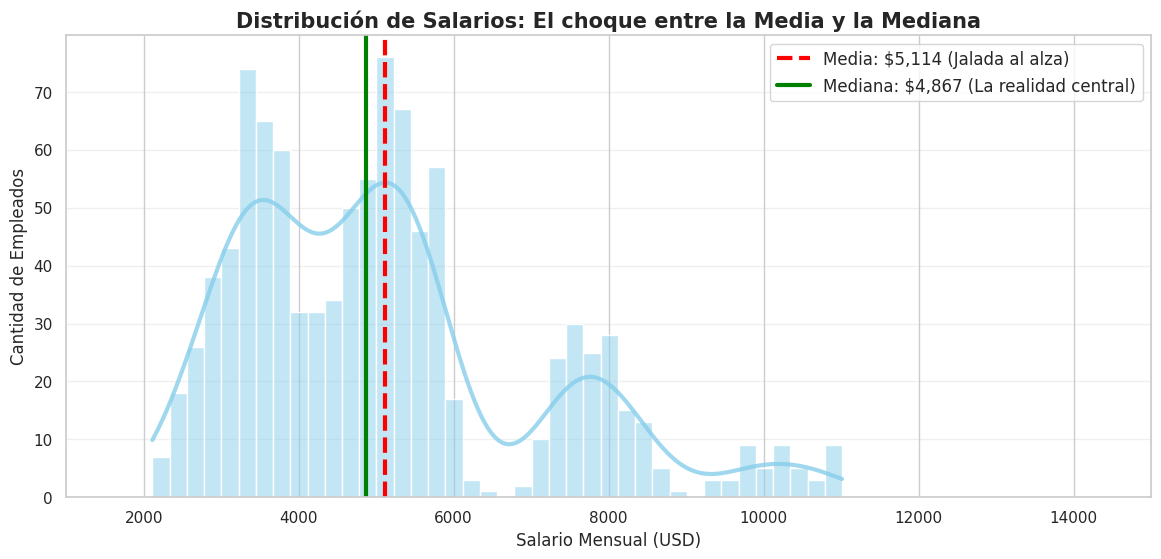

In [25]:
# CÁLCULOS MATEMÁTICOS DEL IMPACTO
# .mean(): Suma todos los salarios y divide por 1000. Es sensible a valores extremos.
media_salario = df_hr["Salario_USD"].mean()

# .median(): Ordena los salarios de menor a mayor y elige el del centro. No le afectan los extremos.
mediana_salario = df_hr["Salario_USD"].median()

# Imprimimos los resultados usando f-strings para dar formato de moneda (comas y decimales)
print("EL EFECTO GRAVEDAD DE LOS SALARIOS ALTOS")
print(f"Media (Promedio Matemático): ${media_salario:,.2f} USD")
print(f"Mediana (El empleado del medio): ${mediana_salario:,.2f} USD")

# Calculamos la brecha entre ambos indicadores para demostrar el sesgo
diferencia = media_salario - mediana_salario
print(f"\n¿Notas la diferencia de ${diferencia:,.2f}? ¡El promedio es engañoso!")

# VISUALIZACIÓN PROFESIONAL (STORYTELLING)
plt.figure(figsize=(14, 6)) # Creamos un lienzo ancho para apreciar mejor la curva

# datos_visuales: Filtramos el DataFrame para excluir valores exageradamente altos (CEOs/Doctorados extremos)
# Esto evita que la "montaña" principal se vea muy pequeña por culpa de un eje X muy largo.
datos_visuales = df_hr[df_hr["Salario_USD"] < 25000]

# sns.histplot:
# bins=40: Define la precisión de las barras.
# kde=True: Agrega la línea de tendencia suave.
# line_kws: Personaliza específicamente la línea de tendencia (color azul marino y grosor 3).
sns.histplot(datos_visuales["Salario_USD"], bins=40, color="skyblue", kde=True,
             line_kws={"linewidth": 3, "color": "navy", "alpha": 0.8})

# plt.axvline: Dibuja las líneas verticales de referencia.
# Media (Roja y segmentada): Representa el promedio "inflado".
plt.axvline(media_salario, color="red", linestyle="dashed", linewidth=3,
            label=f"Media: ${media_salario:,.0f} (Jalada al alza)")

# Mediana (Verde y sólida): Representa el punto real de equilibrio de la población.
plt.axvline(mediana_salario, color="green", linestyle="solid", linewidth=3,
            label=f"Mediana: ${mediana_salario:,.0f} (La realidad central)")

# ESTÉTICA Y LÍMITES
plt.title("Distribución de Salarios: El choque entre la Media y la Mediana", fontsize=15, fontweight="bold")
plt.xlabel("Salario Mensual (USD)", fontsize=12)
plt.ylabel("Cantidad de Empleados", fontsize=12)

# plt.xlim: Enfocamos el gráfico entre los 1,000 y 15,000 USD para ver el detalle de la mayoría.
plt.xlim(1000, 15000)

# plt.legend(): Muestra el cuadro explicativo de las líneas roja y verde.
plt.legend(fontsize=12)

# plt.grid(axis='y'): Agrega líneas horizontales tenues para facilitar la lectura de cantidades.
plt.grid(axis='y', alpha=0.3)

plt.show()

In [26]:
# 1. Comparamos la variabilidad del salario por Nivel Educativo
# Agrupamos y calculamos la media (tendencia) y la desviación estándar (dispersión/variabilidad)
edu_stats = df_hr.groupby("Nivel_Educativo")["Salario_USD"].agg(["mean", "std", "median"]).round(2)

# Renombramos las columnas para que el reporte sea profesional
edu_stats.columns = ["Salario_Promedio", "Desviacion_Estandar (Variabilidad)", "Mediana_Salarial"]

# Ordenamos lógicamente para que el reporte fluya de menor a mayor grado
orden_logico = ['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado']
edu_stats = edu_stats.reindex(orden_logico)

print("ANÁLISIS DE CONSISTENCIA SALARIAL POR NIVEL")
display(edu_stats)

# 2. Un pequeño "Insight" automático
max_var = edu_stats["Desviacion_Estandar (Variabilidad)"].idxmax()
print(f"\nEl nivel '{max_var}' tiene la mayor desviación estándar.")
print("Esto significa que en este grupo los sueldos son más desiguales o dependen más de la edad/experiencia.")

ANÁLISIS DE CONSISTENCIA SALARIAL POR NIVEL


,Salario_Promedio,Desviacion_Estandar (Variabilidad),Mediana_Salarial
Nivel_Educativo,,,
Bachiller,3051.25,444.15,3041.80
Técnico,3726.34,433.37,3717.31
Profesional,5252.10,419.55,5232.86
Maestría,7793.79,423.22,7775.12
Doctorado,10204.58,484.31,10200.10



El nivel 'Doctorado' tiene la mayor desviación estándar.
Esto significa que en este grupo los sueldos son más desiguales o dependen más de la edad/experiencia.
